**Enrolment number(s):** XXXXXXXX

# Problem 2 — German census 2022

## 2.1 Import and data conventions

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA = "./data_census/"
# IDs are read as strings: they are identifiers, and numeric parsing would invite accidental arithmetic
census = pd.read_csv(DATA + "data_census.csv", sep=";", dtype={"MunicipalityID": str})
locations = pd.read_csv(DATA + "municipality-locations.csv", sep=";", dtype={"MunicipalityID": str})

AGES = ["<=3", "3-5", "6-14", "15-17", "18-24", "25-29", "30-39", "40-49", "50-64", "65-74", ">=75"]
census["Age"] = pd.Categorical(census["Age"], categories=AGES + ["Overall"], ordered=True)

census.head()

,Municipality,MunicipalityID,Age,Marital status,Gender,Count
0,Enzen,72325008032,40-49,Overall,Overall,3
1,Bernitt,130725252013,Overall,Married,Male,319
2,Leidenborn,72325001259,30-39,Divorced,Female,0
3,Schwielowsee,120690590590,50-64,Overall,Male,1450
4,Heßheim,73385006012,40-49,Overall,Female,175


**Checks.** The national total is stored as municipality `Overall` with ID `0`. Only there do
attribute combinations appear twice, and only for the statuses Married, Divorced and Widowed.
The two rows are most likely the two sub-groups that the meta file says are merged into "married":
marriage and registered partnership (correspondingly divorced / partnership dissolved, widowed /
partner deceased). Their sum matches the sum over all municipalities, so we add the two rows. All
municipalities are already unique per (Age, Marital status, Gender).

In [27]:
KEY = ["MunicipalityID", "Age", "Marital status", "Gender"]
print("duplicated keys per municipality:",
      list(census[census.duplicated(KEY, keep=False)]["MunicipalityID"].unique()))

census = (census.groupby(KEY, observed=True, as_index=False)
          .agg(Municipality=("Municipality", "first"), Count=("Count", "sum"))
          [["Municipality"] + KEY + ["Count"]])

germany = census[census["MunicipalityID"] == "0"]
muni = census[census["MunicipalityID"] != "0"]

# check: national counts after summing vs. sum over municipalities
chk = pd.DataFrame({
    "national": germany.query("Age == 'Overall' and Gender == 'Overall'")
                       .set_index("Marital status")["Count"],
    "sum of municipalities": muni.query("Age == 'Overall' and Gender == 'Overall'")
                                 .groupby("Marital status")["Count"].sum(),
})
print(chk)

print(f"{muni['MunicipalityID'].nunique()} municipalities, "
      f"{muni['Municipality'].nunique()} distinct names (names are not unique)")
print("municipalities without location:",
      len(set(muni["MunicipalityID"]) - set(locations["MunicipalityID"])))

duplicated keys per municipality: ['0']
                national  sum of municipalities
Marital status                                 
Divorced         6355346                6355660
Married         35181394               35181282
No info           730137                 721900
Overall         82719540               82711282
Single          34765559               34765588
Widowed          5687100                5687075
10786 municipalities, 10759 distinct names (names are not unique)
municipalities without location: 0


**Totals vs. sums.** Sub-group sums do not exactly reproduce the `Overall` rows: some rows are masked,
and even complete groups differ by a few persons (e.g. Gröde: 9 residents, but 4 women + 6 men).
We therefore always read totals from the `Overall` rows rather than summing sub-groups.

In [28]:
def select(df, age="Overall", marital="Overall", gender="Overall"):
    """Rows for one slice; pass None to keep an attribute resolved."""
    m = pd.Series(True, index=df.index)
    for col, val in [("Age", age), ("Marital status", marital), ("Gender", gender)]:
        if val is not None:
            m &= df[col] == val
    return df[m]

totals = select(muni).set_index("MunicipalityID")["Count"].rename("residents")
by_gender = select(muni, gender=None).query("Gender != 'Overall'") \
    .pivot(index="MunicipalityID", columns="Gender", values="Count")

gap = totals - by_gender.sum(axis=1)
print(f"national total (row 0): {select(germany)['Count'].item():,}")
print(f"sum of municipal totals: {totals.sum():,}")
print(f"municipalities where Male+Female != Overall: {(gap != 0).mean():.0%}, "
      f"max |gap| = {gap.abs().max()}")

national total (row 0): 82,719,540
sum of municipal totals: 82,711,282
municipalities where Male+Female != Overall: 69%, max |gap| = 11


In [29]:
mdf = (totals.to_frame()
       .join(by_gender)
       .join(locations.set_index("MunicipalityID")[["Municipality", "lon", "lat"]]))
mdf.describe()

,residents,Female,Male,lon,lat
count,1.078600e+04,1.078600e+04,1.078600e+04,10786.000000,10786.000000
mean,7.668393e+03,3.897855e+03,3.770544e+03,9.897349,50.861406
std,4.951918e+04,2.531932e+04,2.420118e+04,2.076123,1.959182
min,9.000000e+00,0.000000e+00,4.000000e+00,5.902304,47.408447
25%,6.552500e+02,3.270000e+02,3.272500e+02,8.045413,49.442822
50%,1.797000e+03,8.960000e+02,9.000000e+02,9.783509,50.463915
75%,5.505000e+03,2.782000e+03,2.736000e+03,11.461336,52.490700
max,3.596999e+06,1.839986e+06,1.757012e+06,14.988035,55.020026


## 2.2 Distribution of municipality sizes

Sizes range from 9 to 3.6 million residents, so both charts use a logarithmic size axis.
The histogram uses bins of equal width on that log scale (10 bins per factor of 10).

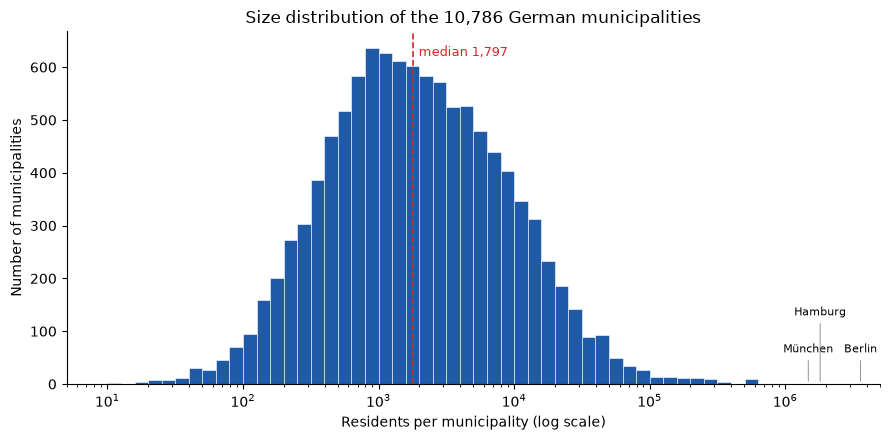

In [30]:
size = mdf["residents"]
bins = np.logspace(0, 7, 71)  # 10^0 … 10^7, 10 bins per decade

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(size, bins=bins, color="#1f5aa6", edgecolor="white", linewidth=0.4)
ax.set_xscale("log")
ax.set_xlim(5, 5e6)
ax.axvline(size.median(), color="#d62728", lw=1.2, ls="--")
ax.text(size.median() * 1.1, ax.get_ylim()[1] * 0.93, f"median {size.median():,.0f}",
        color="#d62728", fontsize=9)
for name, h in [("München", 60), ("Hamburg", 130), ("Berlin", 60)]:
    n = mdf.loc[mdf["Municipality"] == name, "residents"].item()
    ax.annotate(name, (n, 0), xytext=(n, h), ha="center", fontsize=8,
                arrowprops=dict(arrowstyle="-", color="grey", lw=0.6))
ax.set_xlabel("Residents per municipality (log scale)")
ax.set_ylabel("Number of municipalities")
ax.set_title(f"Size distribution of the {len(size):,} German municipalities")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

**Which fraction of people lives in municipalities up to a given size?** We sort municipalities
by size and accumulate their residents (blue). For contrast, the grey curve accumulates the
number of municipalities instead. Denominator: the sum over all municipalities, for consistency.

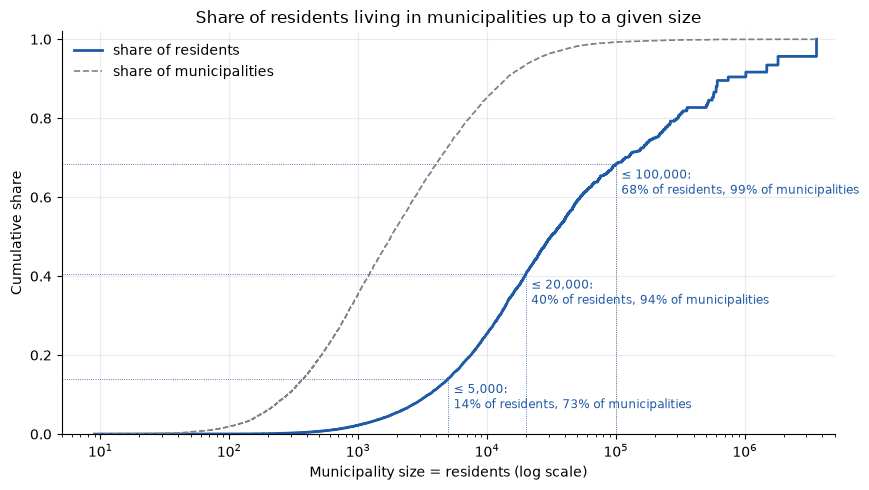

In [31]:
srt = size.sort_values()
people_share = srt.cumsum() / srt.sum()
muni_share = np.arange(1, len(srt) + 1) / len(srt)

fig, ax = plt.subplots(figsize=(9, 5))
ax.step(srt, people_share, where="post", color="#1f5aa6", lw=2, label="share of residents")
ax.step(srt, muni_share, where="post", color="grey", lw=1.2, ls="--", label="share of municipalities")
ax.set_xscale("log")
ax.set_xlim(5, 5e6)
ax.set_ylim(0, 1.02)

for thr in [5_000, 20_000, 100_000]:
    y = srt[srt <= thr].sum() / srt.sum()
    ax.plot([thr, thr], [0, y], color="#1f5aa6", lw=0.6, ls=":")
    ax.plot([5, thr], [y, y], color="#1f5aa6", lw=0.6, ls=":")
    m = (srt <= thr).mean()
    ax.text(thr * 1.1, y - 0.075, f"≤ {thr:,}:\n{y:.0%} of residents, {m:.0%} of municipalities",
            color="#1f5aa6", fontsize=8.5)

ax.set_xlabel("Municipality size = residents (log scale)")
ax.set_ylabel("Cumulative share")
ax.set_title("Share of residents living in municipalities up to a given size")
ax.legend(loc="upper left", frameon=False)
ax.grid(alpha=0.25)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

In [32]:
for thr in [1_000, 5_000, 20_000, 100_000, 1_000_000]:
    print(f"≤ {thr:>9,}: {(srt <= thr).mean():6.1%} of municipalities, "
          f"{srt[srt <= thr].sum() / srt.sum():6.1%} of residents")

≤     1,000:  35.5% of municipalities,   2.2% of residents
≤     5,000:  72.9% of municipalities,  14.0% of residents
≤    20,000:  93.5% of municipalities,  40.5% of residents
≤   100,000:  99.3% of municipalities,  68.4% of residents
≤ 1,000,000: 100.0% of municipalities,  90.4% of residents
